# HW12 – Последовательности и время (PyTorch): базовая классификация временных рядов (TSC)

## 1. Импорты и общие настройки

In [19]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Используемое устройство: cuda


# 2. Загрузка данных

=== Текущая директория ===
Текущая директория: /content/aie-devicheva-maria
Содержимое: ['.git', 'README.md', 'homeworks', 'project', 'LICENSE', 'SECURITY.md', '.gitignore', '.gitattributes']

✓ Мы находимся в репозитории aie-devicheva-maria

=== Поиск датасета S12-hw-dataset.csv ===

Найден: ./homeworks/HW12/data/S12-hw-dataset.csv

Загружаем: ./homeworks/HW12/data/S12-hw-dataset.csv

=== Данные загружены ===
Размер датасета: (4320, 2)

Колонки: ['date', 'target']

Первые 5 строк:
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62

Диапазон дат: 2025-01-01 00:00:00 до 2025-06-29 23:00:00

=== Пропуски ===
date      0
target    0
dtype: int64

=== Статистики target ===
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype

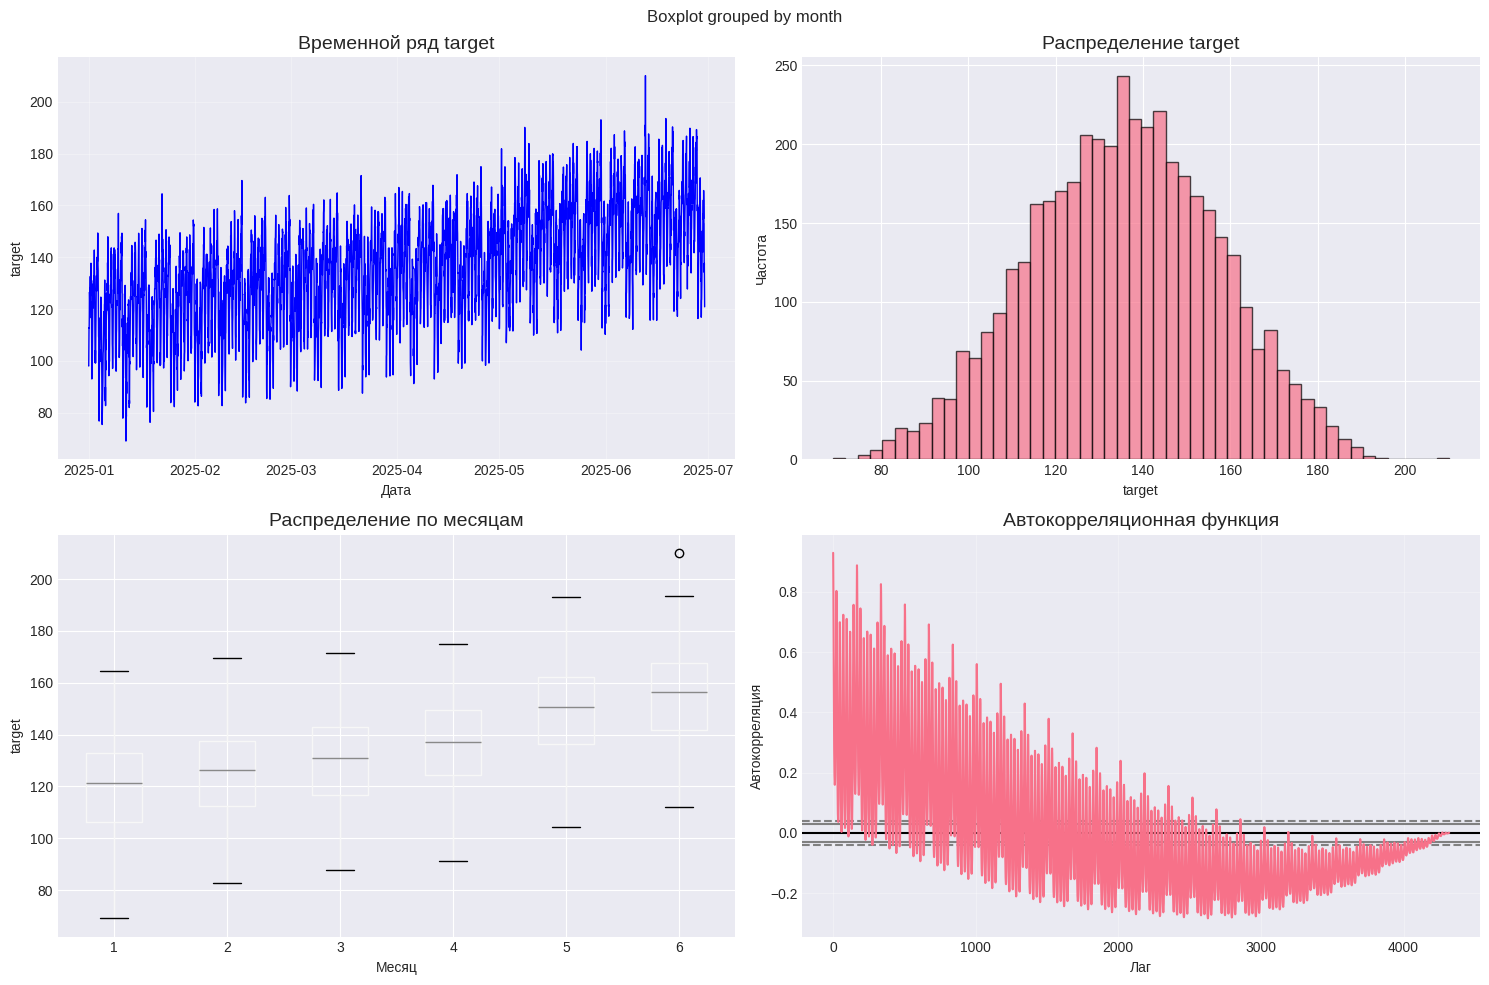


=== Анализ ряда ===
Тренд: Не выражен
Выбросы (за 3 сигмы): 2 наблюдений
Коэффициент вариации: 0.1577

Данные успешно загружены из GitHub репозитория!


In [20]:
# Шаг 2: Загрузка и первичный анализ данных

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

print("=== Текущая директория ===")
print(f"Текущая директория: {os.getcwd()}")
print(f"Содержимое: {os.listdir('.')}")

# Проверяем, находимся ли мы в клонированном репозитории
if 'aie-devicheva-maria' in os.getcwd():
    print("\n✓ Мы находимся в репозитории aie-devicheva-maria")
else:
    print("\n⚠ Мы не в репозитории. Клонируем...")
    !git clone https://github.com/MariaDevicheva/aie-devicheva-maria.git
    os.chdir('aie-devicheva-maria')
    print(f"Перешли в: {os.getcwd()}")

# Поиск датасета
print("\n=== Поиск датасета S12-hw-dataset.csv ===\n")

# Ищем файл во всей структуре
found_files = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if 'S12-hw-dataset' in file and file.endswith('.csv'):
            full_path = os.path.join(root, file)
            found_files.append(full_path)
            print(f"Найден: {full_path}")

if found_files:
    # Берем первый найденный файл
    file_path = found_files[0]
    print(f"\nЗагружаем: {file_path}")
    df = pd.read_csv(file_path)
else:
    print("\nДатасет не найден в репозитории!")
    print("Пожалуйста, проверьте, что файл S12-hw-dataset.csv есть в репозитории")
    print("Возможные места:")
    print("  - homeworks/HW12/data/")
    print("  - homeworks/HW12/")
    print("  - data/")
    df = None

# Анализ данных
if df is not None:
    print(f"\n=== Данные загружены ===")
    print(f"Размер датасета: {df.shape}")
    print(f"\nКолонки: {df.columns.tolist()}")
    print(f"\nПервые 5 строк:")
    print(df.head())

    # Преобразование date в datetime и сортировка
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    print(f"\nДиапазон дат: {df['date'].min()} до {df['date'].max()}")

    # Проверка пропусков
    print(f"\n=== Пропуски ===")
    print(df.isnull().sum())

    # Базовые статистики target
    print(f"\n=== Статистики target ===")
    print(df['target'].describe())

    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # График временного ряда
    axes[0, 0].plot(df['date'], df['target'], linewidth=1, color='blue')
    axes[0, 0].set_title('Временной ряд target', fontsize=14)
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel('target')
    axes[0, 0].grid(True, alpha=0.3)

    # Распределение
    axes[0, 1].hist(df['target'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Распределение target', fontsize=14)
    axes[0, 1].set_xlabel('target')
    axes[0, 1].set_ylabel('Частота')

    # Boxplot по месяцам
    df['month'] = df['date'].dt.month
    df.boxplot(column='target', by='month', ax=axes[1, 0])
    axes[1, 0].set_title('Распределение по месяцам', fontsize=14)
    axes[1, 0].set_xlabel('Месяц')
    axes[1, 0].set_ylabel('target')

    # Автокорреляция
    autocorrelation_plot(df['target'], ax=axes[1, 1])
    axes[1, 1].set_title('Автокорреляционная функция', fontsize=14)
    axes[1, 1].set_xlabel('Лаг')
    axes[1, 1].set_ylabel('Автокорреляция')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Создаем папку и сохраняем
    os.makedirs('homeworks/HW12/artifacts/figures', exist_ok=True)
    plt.savefig('homeworks/HW12/artifacts/figures/initial_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Анализ ряда
    print("\n=== Анализ ряда ===")
    trend = abs(df['target'].diff().mean())
    trend_msg = 'Присутствует' if trend > 0.01 * df['target'].std() else 'Не выражен'
    print(f"Тренд: {trend_msg}")

    outliers = sum(np.abs(df['target'] - df['target'].mean()) > 3 * df['target'].std())
    print(f"Выбросы (за 3 сигмы): {outliers} наблюдений")

    cv = df['target'].std() / df['target'].mean()
    print(f"Коэффициент вариации: {cv:.4f}")

    print("\nДанные успешно загружены из GitHub репозитория!")
else:
    print("Не удалось загрузить данные. Проверьте наличие файла в репозитории.")

In [21]:
# Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Настройка путей для сохранения на Google Drive
DRIVE_BASE = '/content/drive/MyDrive/AIE-SEMINARS'
HW12_DRIVE_PATH = os.path.join(DRIVE_BASE, 'HW12')

# Создаем структуру папок на Google Drive
os.makedirs(HW12_DRIVE_PATH, exist_ok=True)
os.makedirs(os.path.join(HW12_DRIVE_PATH, 'artifacts'), exist_ok=True)
os.makedirs(os.path.join(HW12_DRIVE_PATH, 'artifacts', 'figures'), exist_ok=True)

print(f"Артефакты будут сохраняться в: {HW12_DRIVE_PATH}")

# Функция для сохранения графиков на Drive
def save_figure_to_drive(fig, filename):
    """Сохраняет график на Google Drive"""
    full_path = os.path.join(HW12_DRIVE_PATH, 'artifacts', 'figures', filename)
    fig.savefig(full_path, dpi=100, bbox_inches='tight')
    print(f"График сохранен: {full_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакты будут сохраняться в: /content/drive/MyDrive/AIE-SEMINARS/HW12


# 3. Корректный temporal split (разбиение по времени)

=== Разбиение данных по времени ===
Всего наблюдений: 4320
Train: 2592 наблюдений
  Период: 2025-01-01 00:00:00 до 2025-04-18 23:00:00
Validation: 864 наблюдений
  Период: 2025-04-19 00:00:00 до 2025-05-24 23:00:00
Test: 864 наблюдений
  Период: 2025-05-25 00:00:00 до 2025-06-29 23:00:00

=== Проверка временного порядка ===
Train последняя дата: 2025-04-18 23:00:00
Validation первая дата: 2025-04-19 00:00:00
Validation последняя дата: 2025-05-24 23:00:00
Test первая дата: 2025-05-25 00:00:00
Разрывы между split: Нет
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/series_split.png


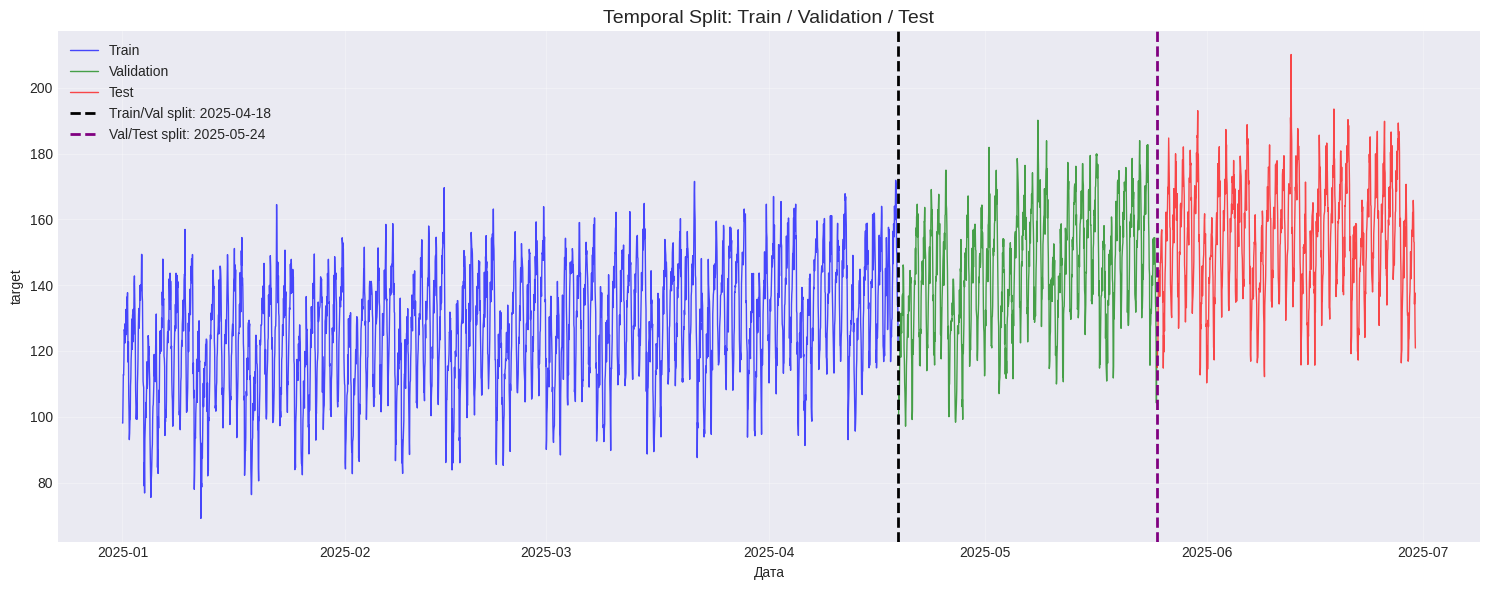


ПОЧЕМУ RANDOM SPLIT НЕКОРРЕКТЕН ДЛЯ ВРЕМЕННЫХ РЯДОВ:

1. ВРЕМЕННАЯ ЗАВИСИМОСТЬ:
   Значения в будущем зависят от прошлых наблюдений. Random split
   нарушает эту естественную структуру данных.

2. УТЕЧКА ДАННЫХ ИЗ БУДУЩЕГО:
   При random split будущие значения могут попасть в обучающую выборку,
   а прошлые - в тестовую. Модель может "увидеть" то, что должно быть
   неизвестно в момент прогнозирования.

3. НЕРЕАЛИСТИЧНАЯ ОЦЕНКА КАЧЕСТВА:
   В реальных задачах прогнозирования мы предсказываем будущее на основе
   прошлого. Random split создает искусственную ситуацию, где модель
   может использовать будущую информацию.

4. НАРУШЕНИЕ СЕЗОННЫХ ПАТТЕРНОВ:
   Random split может разорвать сезонные циклы, перемешивая данные
   из разных временных периодов.

5. АВТОКОРРЕЛЯЦИЯ:
   Временные ряды обладают автокорреляцией. Random split делает
   наблюдения в train и test некоррелированными, что не соответствует
   реальности.


=== Рекомендации ===
Всегда использовать temporal split для временны

In [22]:
# Шаг 3: Корректный temporal split

# Определение границ split
n = len(df)
train_size = int(0.6 * n)
val_size = int(0.2 * n)
test_size = n - train_size - val_size

# Разбиение по времени
train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size+val_size].copy()
test_df = df.iloc[train_size+val_size:].copy()

print("=== Разбиение данных по времени ===")
print(f"Всего наблюдений: {n}")
print(f"Train: {len(train_df)} наблюдений")
print(f"  Период: {train_df['date'].min()} до {train_df['date'].max()}")
print(f"Validation: {len(val_df)} наблюдений")
print(f"  Период: {val_df['date'].min()} до {val_df['date'].max()}")
print(f"Test: {len(test_df)} наблюдений")
print(f"  Период: {test_df['date'].min()} до {test_df['date'].max()}")

# Проверка, что данные идут в хронологическом порядке
print(f"\n=== Проверка временного порядка ===")
print(f"Train последняя дата: {train_df['date'].iloc[-1]}")
print(f"Validation первая дата: {val_df['date'].iloc[0]}")
print(f"Validation последняя дата: {val_df['date'].iloc[-1]}")
print(f"Test первая дата: {test_df['date'].iloc[0]}")
print(f"Разрывы между split: {'Нет' if val_df['date'].iloc[0] > train_df['date'].iloc[-1] else 'Есть'}")

# Визуализация split
fig, ax = plt.subplots(figsize=(15, 6))

# Рисуем три части данных разными цветами
ax.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.7, linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', color='green', alpha=0.7, linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', color='red', alpha=0.7, linewidth=1)

# Добавляем вертикальные линии разделения
ax.axvline(x=train_df['date'].iloc[-1], color='black', linestyle='--', linewidth=2,
           label=f'Train/Val split: {train_df["date"].iloc[-1].strftime("%Y-%m-%d")}')
ax.axvline(x=val_df['date'].iloc[-1], color='purple', linestyle='--', linewidth=2,
           label=f'Val/Test split: {val_df["date"].iloc[-1].strftime("%Y-%m-%d")}')

ax.set_title('Temporal Split: Train / Validation / Test', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Сохраняем график на Google Drive
save_figure_to_drive(fig, 'series_split.png')
plt.show()

# Объяснение, почему random split некорректен
print("\n" + "="*60)
print("ПОЧЕМУ RANDOM SPLIT НЕКОРРЕКТЕН ДЛЯ ВРЕМЕННЫХ РЯДОВ:")
print("="*60)
print("""
1. ВРЕМЕННАЯ ЗАВИСИМОСТЬ:
   Значения в будущем зависят от прошлых наблюдений. Random split
   нарушает эту естественную структуру данных.

2. УТЕЧКА ДАННЫХ ИЗ БУДУЩЕГО:
   При random split будущие значения могут попасть в обучающую выборку,
   а прошлые - в тестовую. Модель может "увидеть" то, что должно быть
   неизвестно в момент прогнозирования.

3. НЕРЕАЛИСТИЧНАЯ ОЦЕНКА КАЧЕСТВА:
   В реальных задачах прогнозирования мы предсказываем будущее на основе
   прошлого. Random split создает искусственную ситуацию, где модель
   может использовать будущую информацию.

4. НАРУШЕНИЕ СЕЗОННЫХ ПАТТЕРНОВ:
   Random split может разорвать сезонные циклы, перемешивая данные
   из разных временных периодов.

5. АВТОКОРРЕЛЯЦИЯ:
   Временные ряды обладают автокорреляцией. Random split делает
   наблюдения в train и test некоррелированными, что не соответствует
   реальности.
""")

print("\n=== Рекомендации ===")
print("Всегда использовать temporal split для временных рядов")
print("Сохранять хронологический порядок наблюдений")
print("Тестовая выборка должна быть строго после валидационной")
print("Признаки строить только на основе прошлых данных")
print(f"\nГрафик сохранен на Google Drive: {HW12_DRIVE_PATH}/artifacts/figures/series_split.png")

# 4. Построение признаков для baseline-моделей

Создание признаков на полном датасете...

Размеры до удаления NaN:
Train: 2592
Val: 864
Test: 864

Размеры после удаления NaN:
Train: 2578
Val: 864
Test: 864

Используемые признаки (7):
  - lag_1
  - lag_7
  - lag_14
  - rolling_mean_7
  - rolling_std_7
  - day_of_week_sin
  - day_of_week_cos

Размеры признаковых матриц:
X_train: (2578, 7)
X_val: (864, 7)
X_test: (864, 7)
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/feature_examples.png


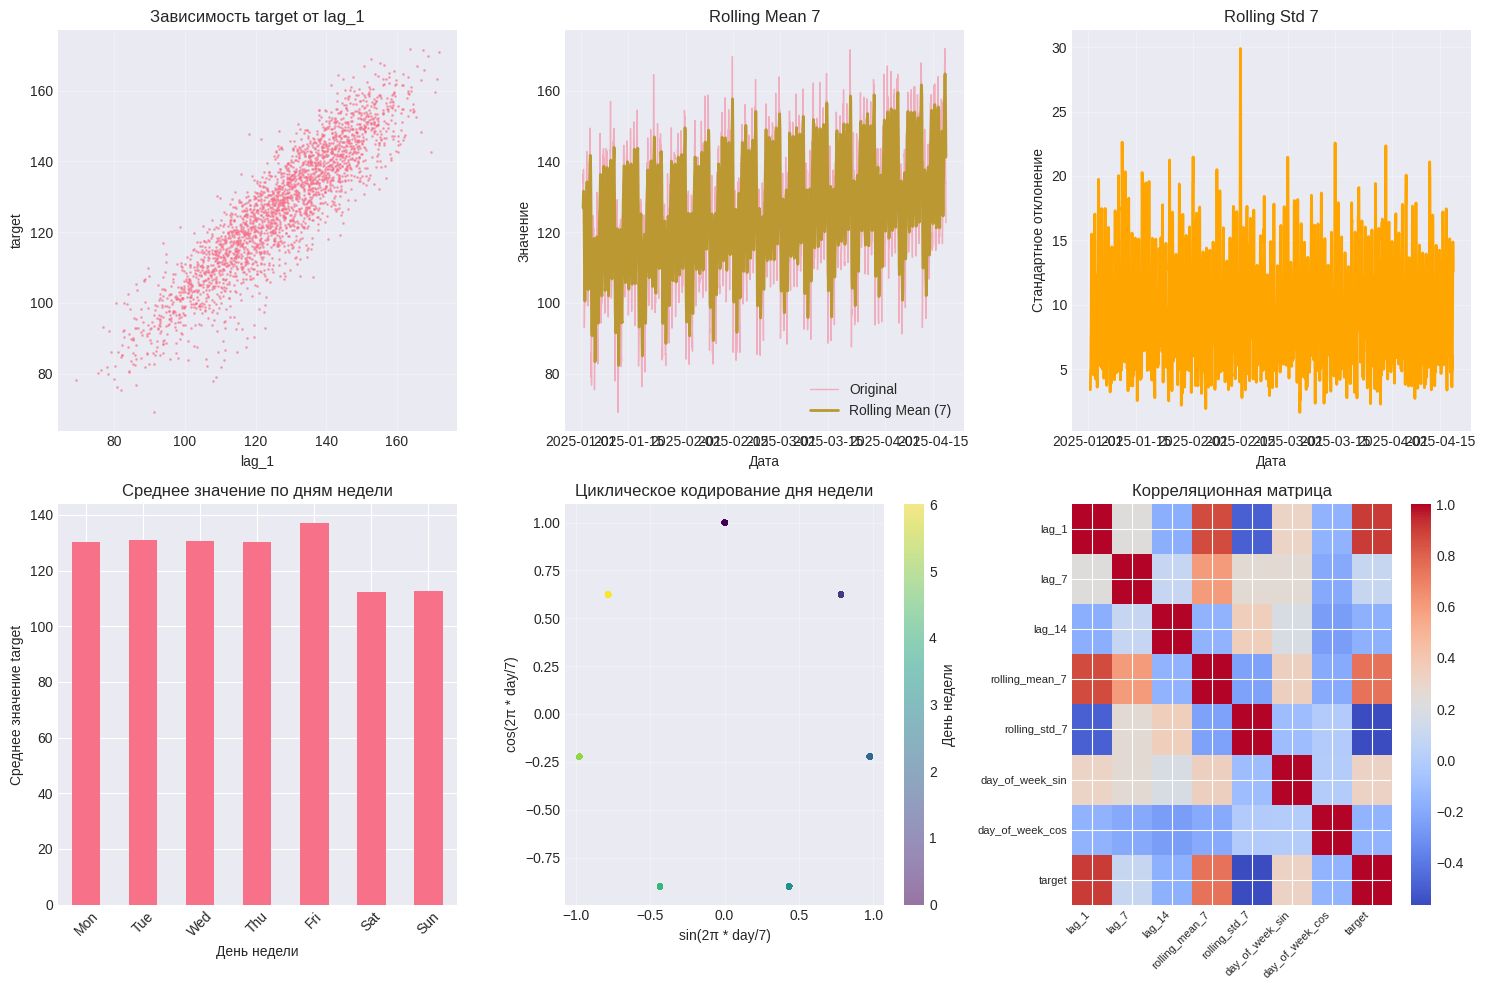


=== Статистика признаков ===
Корреляция с target:
  lag_1: 0.9027
  lag_7: 0.0931
  lag_14: -0.1658
  rolling_mean_7: 0.7480
  rolling_std_7: -0.5635
  day_of_week_sin: 0.3187
  day_of_week_cos: -0.1459


In [23]:
# ============================================================================
# Шаг 4: Построение признаков для baseline-моделей
# ============================================================================

def create_features(df, window_sizes=[7, 14]):
    """
    Создание лаговых, rolling и календарных признаков.
    ВАЖНО: Применяем ко всему датасету для сохранения непрерывности лагов.
    """
    df = df.copy()

    # 1. Лаговые признаки (используем прошлые значения)
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)

    # 2. Rolling статистики (только на основе прошлых данных)
    for window in window_sizes:
        df[f'rolling_mean_{window}'] = df['target'].rolling(window=window, min_periods=1).mean()
        df[f'rolling_std_{window}'] = df['target'].rolling(window=window, min_periods=1).std()

    # 3. Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear

    # Циклическое кодирование
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

# ============================================================================
# Создаём признаки ДО split
# ============================================================================
print("Создание признаков на полном датасете...")
df = create_features(df)  # Применяем к исходному df до разбиения

# Теперь делаем split уже с готовыми признаками
train_features = df.iloc[:train_size].copy()
val_features = df.iloc[train_size:train_size+val_size].copy()
test_features = df.iloc[train_size+val_size:].copy()

# Удаляем строки с NaN (появились из-за лагов в начале ряда)
print("\nРазмеры до удаления NaN:")
print(f"Train: {len(train_features)}")
print(f"Val: {len(val_features)}")
print(f"Test: {len(test_features)}")

train_features = train_features.dropna().reset_index(drop=True)
val_features = val_features.dropna().reset_index(drop=True)
test_features = test_features.dropna().reset_index(drop=True)

print("\nРазмеры после удаления NaN:")
print(f"Train: {len(train_features)}")
print(f"Val: {len(val_features)}")
print(f"Test: {len(test_features)}")

# Выбор признаков для модели
feature_cols = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'day_of_week_sin', 'day_of_week_cos'
]

print(f"\nИспользуемые признаки ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

# Подготовка данных для моделей
X_train = train_features[feature_cols]
y_train = train_features['target']

X_val = val_features[feature_cols]
y_val = val_features['target']

X_test = test_features[feature_cols]
y_test = test_features['target']

print(f"\nРазмеры признаковых матриц:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

# ============================================================================
# Визуализация созданных признаков
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Лаговые признаки
axes[0, 0].scatter(train_features['lag_1'], train_features['target'], alpha=0.5, s=1)
axes[0, 0].set_xlabel('lag_1')
axes[0, 0].set_ylabel('target')
axes[0, 0].set_title('Зависимость target от lag_1')
axes[0, 0].grid(True, alpha=0.3)

# 2. Rolling mean
axes[0, 1].plot(train_features['date'], train_features['target'], label='Original', alpha=0.5, linewidth=1)
axes[0, 1].plot(train_features['date'], train_features['rolling_mean_7'], label='Rolling Mean (7)', linewidth=2)
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Значение')
axes[0, 1].set_title('Rolling Mean 7')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Rolling std
axes[0, 2].plot(train_features['date'], train_features['rolling_std_7'], color='orange', linewidth=2)
axes[0, 2].set_xlabel('Дата')
axes[0, 2].set_ylabel('Стандартное отклонение')
axes[0, 2].set_title('Rolling Std 7')
axes[0, 2].grid(True, alpha=0.3)

# 4. Распределение по дням недели
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
train_features['day_of_week_name'] = train_features['date'].dt.dayofweek
train_features.groupby('day_of_week_name')['target'].mean().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Среднее значение target')
axes[1, 0].set_title('Среднее значение по дням недели')
axes[1, 0].set_xticklabels(day_names, rotation=45)

# 5. Циклическое кодирование дня недели
scatter = axes[1, 1].scatter(train_features['day_of_week_sin'], train_features['day_of_week_cos'],
                             c=train_features['day_of_week'], alpha=0.5, s=10, cmap='viridis')
axes[1, 1].set_xlabel('sin(2π * day/7)')
axes[1, 1].set_ylabel('cos(2π * day/7)')
axes[1, 1].set_title('Циклическое кодирование дня недели')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='День недели')

# 6. Корреляционная матрица признаков
corr_matrix = train_features[feature_cols + ['target']].corr()
im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
axes[1, 2].set_xticks(range(len(corr_matrix.columns)))
axes[1, 2].set_yticks(range(len(corr_matrix.columns)))
axes[1, 2].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
axes[1, 2].set_yticklabels(corr_matrix.columns, fontsize=8)
axes[1, 2].set_title('Корреляционная матрица')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()

# Сохраняем график
save_figure_to_drive(fig, 'feature_examples.png')
plt.show()

print("\n=== Статистика признаков ===")
print(f"Корреляция с target:")
for col in feature_cols:
    corr = train_features[col].corr(train_features['target'])
    print(f"  {col}: {corr:.4f}")

# 5. Baseline эксперименты (B1, B2, B3)

B1: Naive baseline (прогноз = последнее значение)
Validation: MAE=24.0226, RMSE=28.3675, MAPE=15.73%
Test: MAE=32.0115, RMSE=36.0061, MAPE=19.79%

B2: Moving Average baseline (окно 7)
Validation: MAE=16.7805, RMSE=20.3242, MAPE=11.40%
Test: MAE=21.3539, RMSE=25.5233, MAPE=13.14%

B3: Ridge regression на лаговых признаках
Validation: MAE=6.6619, RMSE=8.1916, MAPE=4.59%
Test: MAE=7.6508, RMSE=9.3797, MAPE=4.91%

Коэффициенты модели Ridge:
  lag_1: 11.0672
  lag_7: -3.4582
  lag_14: 0.6945
  rolling_mean_7: 5.0102
  rolling_std_7: -2.8812
  day_of_week_sin: 1.1133
  day_of_week_cos: -0.4749

Визуализация сравнения baseline
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/baselines_compare.png


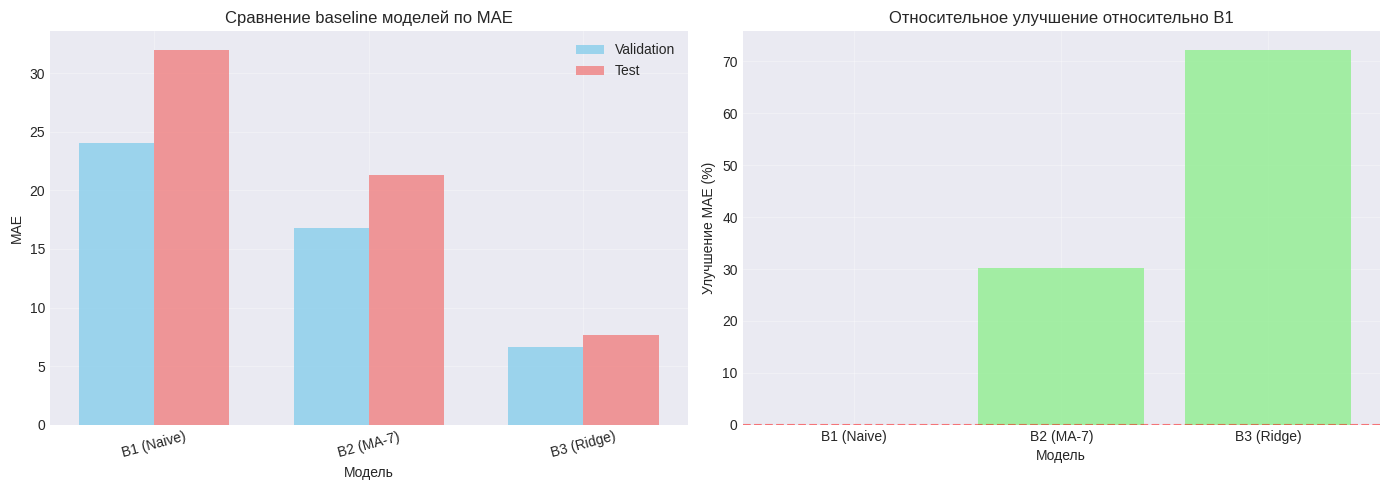


Сохранение результатов

Результаты сохранены в переменную baseline_results
Лучшая baseline модель по validation MAE: B3
  MAE = 6.6619


In [24]:
# ============================================================================
# Шаг 5: Baseline эксперименты (B1, B2, B3)
# ============================================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Функция для расчета метрик
def calculate_metrics(y_true, y_pred):
    """Рассчитывает MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (избегаем деления на ноль)
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.inf

    return mae, rmse, mape

# ============================================================================
# B1: Naive baseline (последнее известное значение)
# ============================================================================
print("="*60)
print("B1: Naive baseline (прогноз = последнее значение)")
print("="*60)

def naive_last_predict(train, val, test, lag=1):
    """
    Прогноз = последнее известное значение.
    Для test используем последнее значение val (не истинное, а последнее доступное)
    """
    val_pred = np.full(len(val), train['target'].iloc[-1])
    # Для test используем последнее значение из train (так как в реальности мы не знаем val)
    test_pred = np.full(len(test), train['target'].iloc[-1])
    return val_pred, test_pred

val_pred_b1, test_pred_b1 = naive_last_predict(train_df, val_df, test_df)

# Метрики B1
b1_val_mae, b1_val_rmse, b1_val_mape = calculate_metrics(val_df['target'], val_pred_b1)
b1_test_mae, b1_test_rmse, b1_test_mape = calculate_metrics(test_df['target'], test_pred_b1)

print(f"Validation: MAE={b1_val_mae:.4f}, RMSE={b1_val_rmse:.4f}, MAPE={b1_val_mape:.2f}%")
print(f"Test: MAE={b1_test_mae:.4f}, RMSE={b1_test_rmse:.4f}, MAPE={b1_test_mape:.2f}%")

# ============================================================================
# B2: Moving Average baseline
# ============================================================================
print("\n" + "="*60)
print("B2: Moving Average baseline (окно 7)")
print("="*60)

def moving_average_predict(train, val, test, window=7):
    """
    Прогноз = скользящее среднее за последние window наблюдений.
    Используем только предсказания, без утечки истинных значений!
    """
    # --- Validation ---
    val_pred = []
    # Начинаем с истории train
    history = train['target'].tolist()

    for i in range(len(val)):
        if len(history) >= window:
            val_pred.append(np.mean(history[-window:]))
        else:
            val_pred.append(np.mean(history))
        # Добавляем ПРЕДСКАЗАНИЕ в историю, а не истинное значение!
        history.append(val_pred[-1])

    # --- Test ---
    test_pred = []
    # Продолжаем ту же историю (train + предсказания val)
    # НЕ используем истинные значения val!

    for i in range(len(test)):
        if len(history) >= window:
            test_pred.append(np.mean(history[-window:]))
        else:
            test_pred.append(np.mean(history))
        # Добавляем ПРЕДСКАЗАНИЕ в историю
        history.append(test_pred[-1])

    return np.array(val_pred), np.array(test_pred)

val_pred_b2, test_pred_b2 = moving_average_predict(train_df, val_df, test_df, window=7)

# Метрики B2
b2_val_mae, b2_val_rmse, b2_val_mape = calculate_metrics(val_df['target'], val_pred_b2)
b2_test_mae, b2_test_rmse, b2_test_mape = calculate_metrics(test_df['target'], test_pred_b2)

print(f"Validation: MAE={b2_val_mae:.4f}, RMSE={b2_val_rmse:.4f}, MAPE={b2_val_mape:.2f}%")
print(f"Test: MAE={b2_test_mae:.4f}, RMSE={b2_test_rmse:.4f}, MAPE={b2_test_mape:.2f}%")

# ============================================================================
# B3: Ridge regression на лаговых признаках
# ============================================================================
print("\n" + "="*60)
print("B3: Ridge regression на лаговых признаках")
print("="*60)

# Масштабирование признаков
# Scaler fit только на train данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Прогнозы
val_pred_b3 = ridge_model.predict(X_val_scaled)
test_pred_b3 = ridge_model.predict(X_test_scaled)

# Метрики B3
b3_val_mae, b3_val_rmse, b3_val_mape = calculate_metrics(y_val, val_pred_b3)
b3_test_mae, b3_test_rmse, b3_test_mape = calculate_metrics(y_test, test_pred_b3)

print(f"Validation: MAE={b3_val_mae:.4f}, RMSE={b3_val_rmse:.4f}, MAPE={b3_val_mape:.2f}%")
print(f"Test: MAE={b3_test_mae:.4f}, RMSE={b3_test_rmse:.4f}, MAPE={b3_test_mape:.2f}%")

# Коэффициенты Ridge
print(f"\nКоэффициенты модели Ridge:")
for col, coef in zip(feature_cols, ridge_model.coef_):
    print(f"  {col}: {coef:.4f}")

# ============================================================================
# Визуализация сравнения baseline
# ============================================================================
print("\n" + "="*60)
print("Визуализация сравнения baseline")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['B1 (Naive)', 'B2 (MA-7)', 'B3 (Ridge)']
val_mae = [b1_val_mae, b2_val_mae, b3_val_mae]
test_mae = [b1_test_mae, b2_test_mae, b3_test_mae]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, val_mae, width, label='Validation', color='skyblue', alpha=0.8)
axes[0].bar(x + width/2, test_mae, width, label='Test', color='lightcoral', alpha=0.8)
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('MAE')
axes[0].set_title('Сравнение baseline моделей по MAE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Относительное улучшение
improvement = [(val_mae[0] - m) / val_mae[0] * 100 for m in val_mae]
axes[1].bar(models, improvement, color='lightgreen', alpha=0.8)
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('Улучшение MAE (%)')
axes[1].set_title('Относительное улучшение относительно B1')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure_to_drive(fig, 'baselines_compare.png')
plt.show()

# ============================================================================
# Сохранение результатов для runs.csv
# ============================================================================
print("\n" + "="*60)
print("Сохранение результатов")
print("="*60)

# Создаем словарь с результатами
baseline_results = {
    'B1': {
        'val_mae': b1_val_mae, 'val_rmse': b1_val_rmse, 'val_mape': b1_val_mape,
        'test_mae': b1_test_mae, 'test_rmse': b1_test_rmse, 'test_mape': b1_test_mape
    },
    'B2': {
        'val_mae': b2_val_mae, 'val_rmse': b2_val_rmse, 'val_mape': b2_val_mape,
        'test_mae': b2_test_mae, 'test_rmse': b2_test_rmse, 'test_mape': b2_test_mape
    },
    'B3': {
        'val_mae': b3_val_mae, 'val_rmse': b3_val_rmse, 'val_mape': b3_val_mape,
        'test_mae': b3_test_mae, 'test_rmse': b3_test_rmse, 'test_mape': b3_test_mape
    }
}

print("\nРезультаты сохранены в переменную baseline_results")
print(f"Лучшая baseline модель по validation MAE: B{np.argmin([b1_val_mae, b2_val_mae, b3_val_mae]) + 1}")
print(f"  MAE = {min([b1_val_mae, b2_val_mae, b3_val_mae]):.4f}")

# 6. Подготовка данных и реализация GRU модели

Подготовка данных для GRU
Train shape: (2592, 1)
Val shape: (864, 1)
Test shape: (864, 1)
Window size: 14

Количество батчей:
Train: 81
Val: 27
Test: 27

Инициализация GRU модели
Модель: GRU
Input size: 1
Hidden size: 64
Num layers: 2
Dropout: 0.2
Optimizer: Adam (lr=0.001)
Loss: MSE

Начало обучения GRU
Epoch  10/100 | Train Loss: 0.143710 | Val Loss: 0.175558 | Val MAE: 0.3345 | LR: 0.001000
Epoch  20/100 | Train Loss: 0.123447 | Val Loss: 0.171945 | Val MAE: 0.3270 | LR: 0.000500
Epoch  30/100 | Train Loss: 0.121615 | Val Loss: 0.168695 | Val MAE: 0.3236 | LR: 0.000500
Epoch  40/100 | Train Loss: 0.119947 | Val Loss: 0.167016 | Val MAE: 0.3218 | LR: 0.000500
Epoch  50/100 | Train Loss: 0.115928 | Val Loss: 0.170196 | Val MAE: 0.3242 | LR: 0.000250
Epoch  60/100 | Train Loss: 0.113753 | Val Loss: 0.172749 | Val MAE: 0.3256 | LR: 0.000125
Epoch  70/100 | Train Loss: 0.112852 | Val Loss: 0.176218 | Val MAE: 0.3288 | LR: 0.000063
Epoch  80/100 | Train Loss: 0.113992 | Val Loss: 0.176246

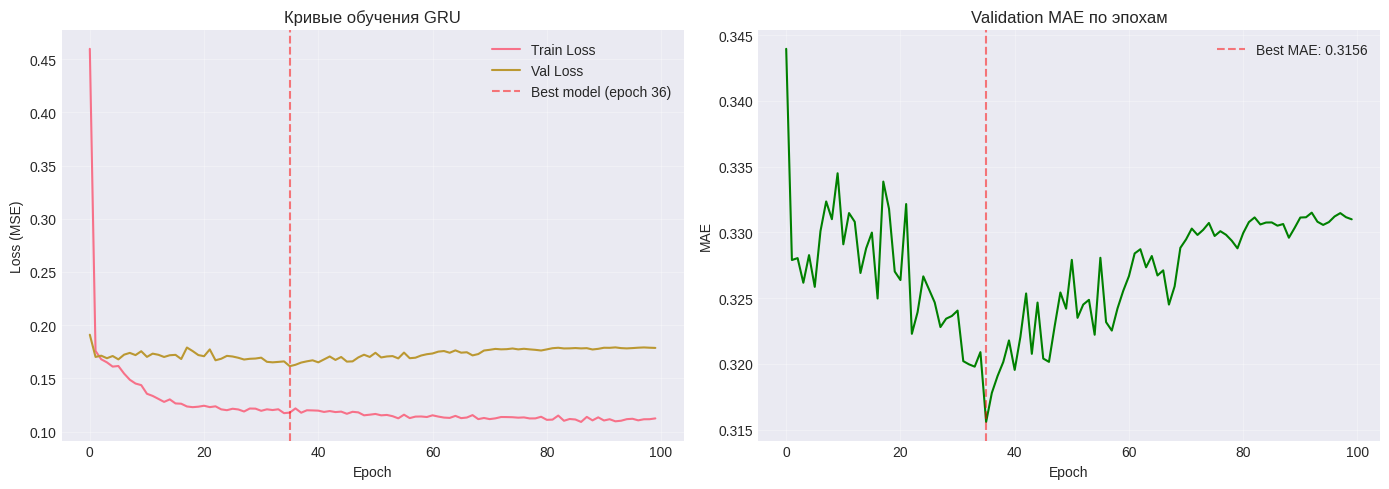


Сохранение конфига модели
Конфиг сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/best_gru_config.json

Лучшая модель GRU:
  Val MAE: 0.3156
  Window size: 14
  Hidden size: 64
  Num layers: 2


In [25]:
# Шаг 6: GRU модель для прогнозирования временных рядов

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

# ============================================
# 1. Класс Dataset для временных рядов
# ============================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size, target_col='target', feature_cols=None):
        """
        data: DataFrame с данными
        window_size: размер окна для GRU
        target_col: название целевой колонки
        feature_cols: список колонок для признаков (если None, используем target)
        """
        self.data = data
        self.window_size = window_size
        self.target_col = target_col

        if feature_cols is None:
            self.feature_cols = [target_col]
        else:
            self.feature_cols = feature_cols

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # Получаем окно признаков (последовательность)
        X = self.data[self.feature_cols].iloc[idx:idx+self.window_size].values
        # Целевое значение (следующий шаг после окна)
        y = self.data[self.target_col].iloc[idx+self.window_size]

        return torch.FloatTensor(X), torch.FloatTensor([y])

# ============================================
# 2. Архитектура GRU модели
# ============================================
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        # Берем последний выход GRU
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# ============================================
# 3. Подготовка данных для GRU
# ============================================
print("="*60)
print("Подготовка данных для GRU")
print("="*60)

# Параметры
window_size = 14  # размер окна (2 недели)
feature_cols_gru = ['target']  # используем только target для прогнозирования

# Масштабирование данных
scaler_gru = StandardScaler()

# Обучаем scaler только на train данных
train_scaled = scaler_gru.fit_transform(train_df[feature_cols_gru])
val_scaled = scaler_gru.transform(val_df[feature_cols_gru])
test_scaled = scaler_gru.transform(test_df[feature_cols_gru])

# Создаем датафреймы со скейлированными данными
train_scaled_df = pd.DataFrame(train_scaled, columns=feature_cols_gru)
val_scaled_df = pd.DataFrame(val_scaled, columns=feature_cols_gru)
test_scaled_df = pd.DataFrame(test_scaled, columns=feature_cols_gru)

print(f"Train shape: {train_scaled_df.shape}")
print(f"Val shape: {val_scaled_df.shape}")
print(f"Test shape: {test_scaled_df.shape}")
print(f"Window size: {window_size}")

# Создаем датасеты
train_dataset = TimeSeriesDataset(train_scaled_df, window_size, 'target', feature_cols_gru)
val_dataset = TimeSeriesDataset(val_scaled_df, window_size, 'target', feature_cols_gru)
test_dataset = TimeSeriesDataset(test_scaled_df, window_size, 'target', feature_cols_gru)

# Создаем DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nКоличество батчей:")
print(f"Train: {len(train_loader)}")
print(f"Val: {len(val_loader)}")
print(f"Test: {len(test_loader)}")

# ============================================
# 4. Инициализация модели и настройка обучения
# ============================================
print("\n" + "="*60)
print("Инициализация GRU модели")
print("="*60)

input_size = len(feature_cols_gru)
model = GRUModel(input_size, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

print(f"Модель: GRU")
print(f"Input size: {input_size}")
print(f"Hidden size: 64")
print(f"Num layers: 2")
print(f"Dropout: 0.2")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: MSE")

# ============================================
# 5. Функции обучения и валидации
# ============================================
def train_epoch(model, loader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    total_loss = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    """Валидация"""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            output = model(X)
            loss = criterion(output, y)
            total_loss += loss.item()

            predictions.extend(output.cpu().numpy())
            targets.extend(y.cpu().numpy())

    # Расчет метрик
    predictions = np.array(predictions).flatten()
    targets = np.array(targets).flatten()

    mae, rmse, mape = calculate_metrics(targets, predictions)

    return total_loss / len(loader), mae, rmse, mape

# ============================================
# 6. Обучение модели
# ============================================
print("\n" + "="*60)
print("Начало обучения GRU")
print("="*60)

num_epochs = 100
best_val_mae = float('inf')
best_epoch = 0

train_losses = []
val_losses = []
val_maes = []

for epoch in range(num_epochs):
    # Обучение
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_mae, val_rmse, val_mape = validate(model, val_loader, criterion, device)

    # Сохранение истории
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)

    # Снижение learning rate
    scheduler.step(val_loss)

    # Сохранение лучшей модели
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch = epoch + 1
        torch.save(model.state_dict(), os.path.join(HW12_DRIVE_PATH, 'best_gru.pt'))

    # Вывод прогресса
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val MAE: {val_mae:.4f} | "
              f"LR: {current_lr:.6f}")

print(f"\nОбучение завершено!")
print(f"Лучшая модель на эпохе {best_epoch} с Val MAE = {best_val_mae:.4f}")

# ============================================
# 7. Визуализация кривых обучения
# ============================================
print("\n" + "="*60)
print("Визуализация кривых обучения")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=1.5)
axes[0].plot(val_losses, label='Val Loss', linewidth=1.5)
axes[0].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'Best model (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Кривые обучения GRU')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val MAE
axes[1].plot(val_maes, color='green', linewidth=1.5)
axes[1].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'Best MAE: {best_val_mae:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Validation MAE по эпохам')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure_to_drive(fig, 'gru_learning_curves.png')
plt.show()

# ============================================
# 8. Сохранение конфига лучшей модели
# ============================================
print("\n" + "="*60)
print("Сохранение конфига модели")
print("="*60)

best_config = {
    'model_type': 'GRU',
    'window_size': window_size,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'input_size': input_size,
    'batch_size': batch_size,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'loss_function': 'MSELoss',
    'seed': 42,
    'scaler': 'StandardScaler',
    'features': feature_cols_gru,
    'best_val_mae': best_val_mae,
    'best_epoch': best_epoch,
    'num_epochs': num_epochs
}

config_path = os.path.join(HW12_DRIVE_PATH, 'best_gru_config.json')
with open(config_path, 'w') as f:
    json.dump(best_config, f, indent=4)

print(f"Конфиг сохранен: {config_path}")
print(f"\nЛучшая модель GRU:")
print(f"  Val MAE: {best_val_mae:.4f}")
print(f"  Window size: {window_size}")
print(f"  Hidden size: 64")
print(f"  Num layers: 2")

# 7. Оценка GRU на тесте и создание финальных артефактов

Загрузка лучшей GRU модели
Конфиг загружен:
  Window size: 14
  Hidden size: 64
  Num layers: 2
Модель загружена: /content/drive/MyDrive/AIE-SEMINARS/HW12/best_gru.pt

Прогноз на тестовых данных
GRU на тестовых данных:
  MAE: 7.6544
  RMSE: 9.4427
  MAPE: 4.93%

Визуализация прогноза
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/best_forecast_test.png


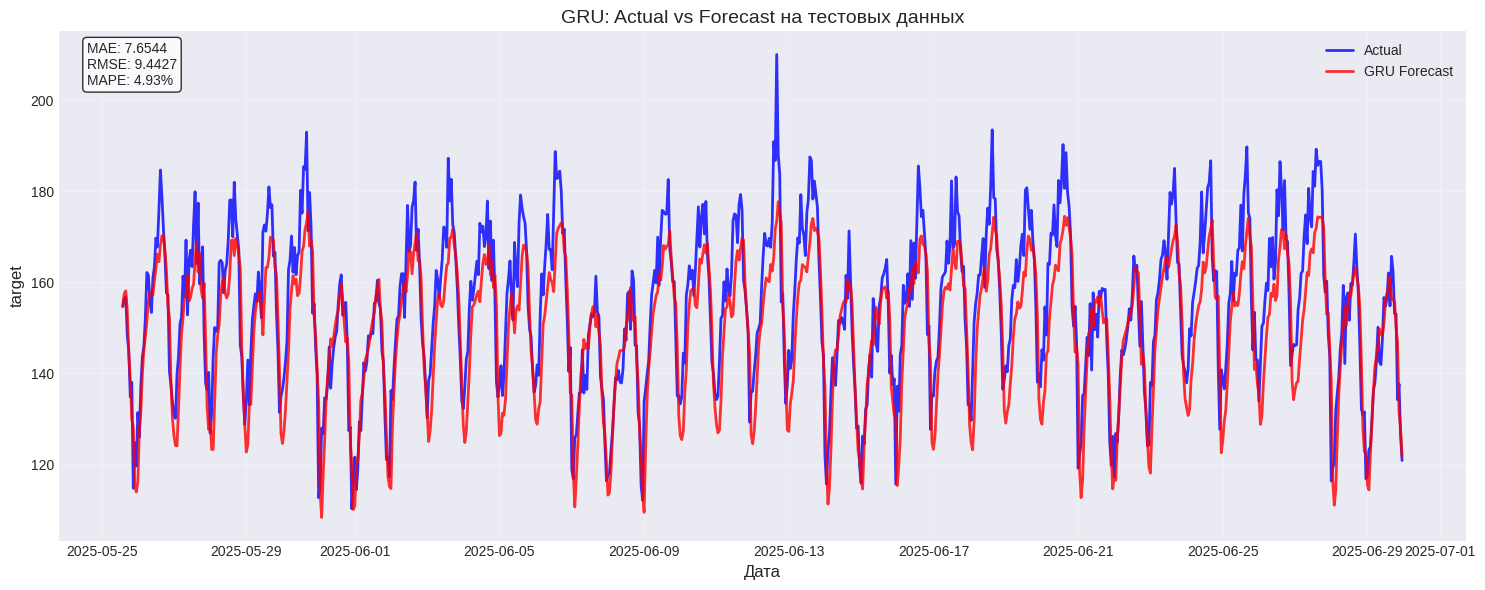


Анализ остатков
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/residuals_best.png


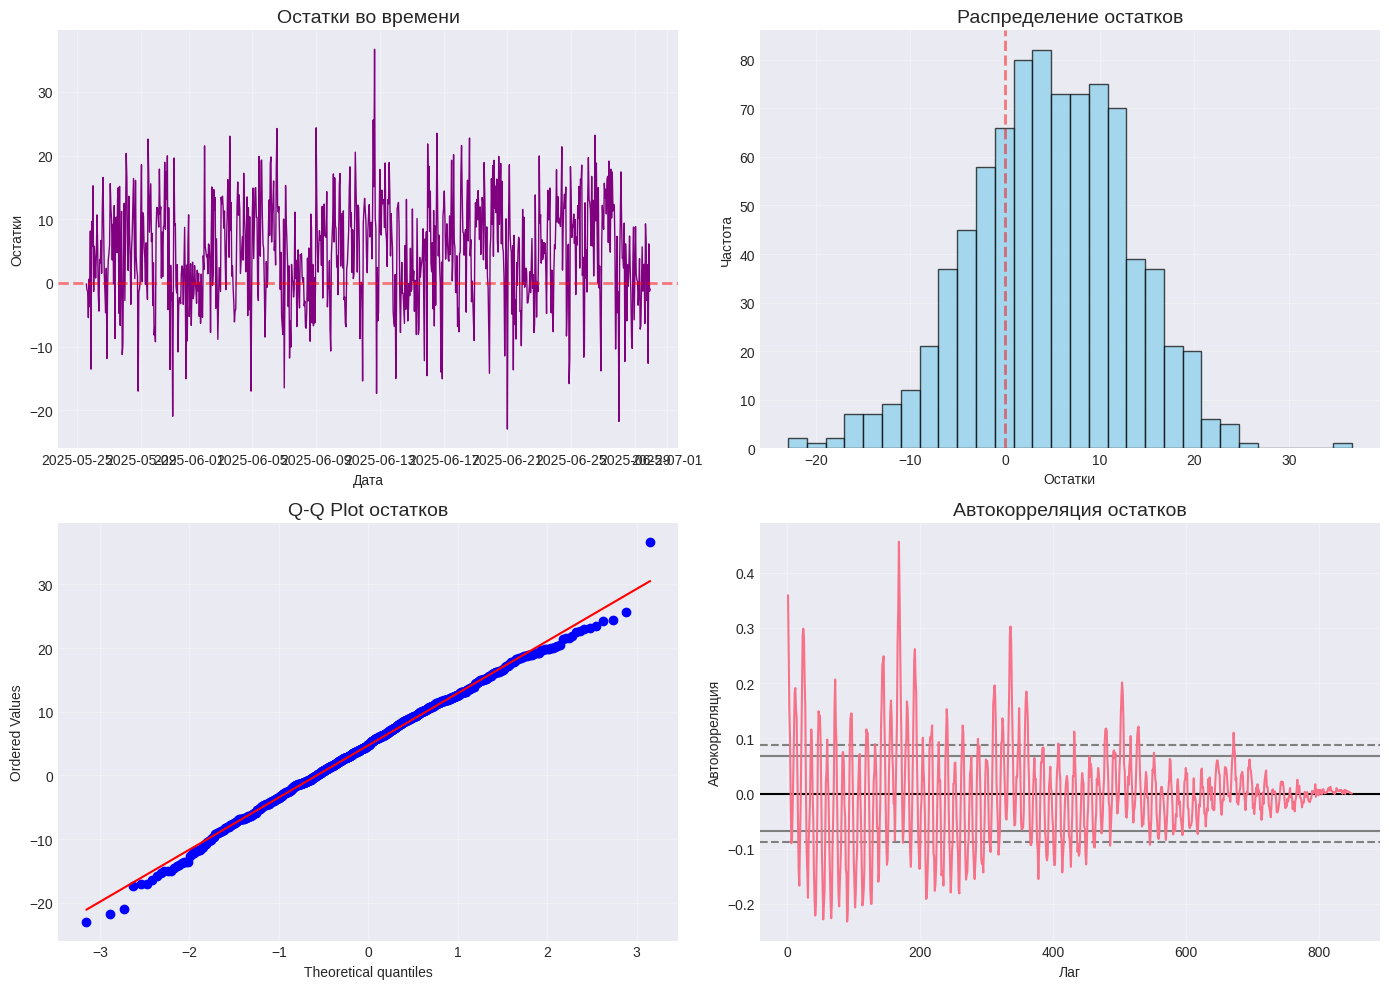


Статистика остатков:
  Среднее: 4.721541
  Стандартное отклонение: 8.177547
  Максимум: 36.676514
  Минимум: -22.943840

Создание runs.csv
✓ runs.csv сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/runs.csv

Финальное сравнение всех моделей
     Model   Val MAE  Test MAE  Test RMSE  Test MAPE (%)
B1 (Naive) 24.022639 32.011516  36.006079      19.794289
 B2 (MA-7) 16.780501 21.353924  25.523268      13.142748
B3 (Ridge)  6.661937  7.650835   9.379712       4.906574
  R1 (GRU)  0.315584  7.654375   9.442734       4.928242
График сохранен: /content/drive/MyDrive/AIE-SEMINARS/HW12/artifacts/figures/final_comparison.png


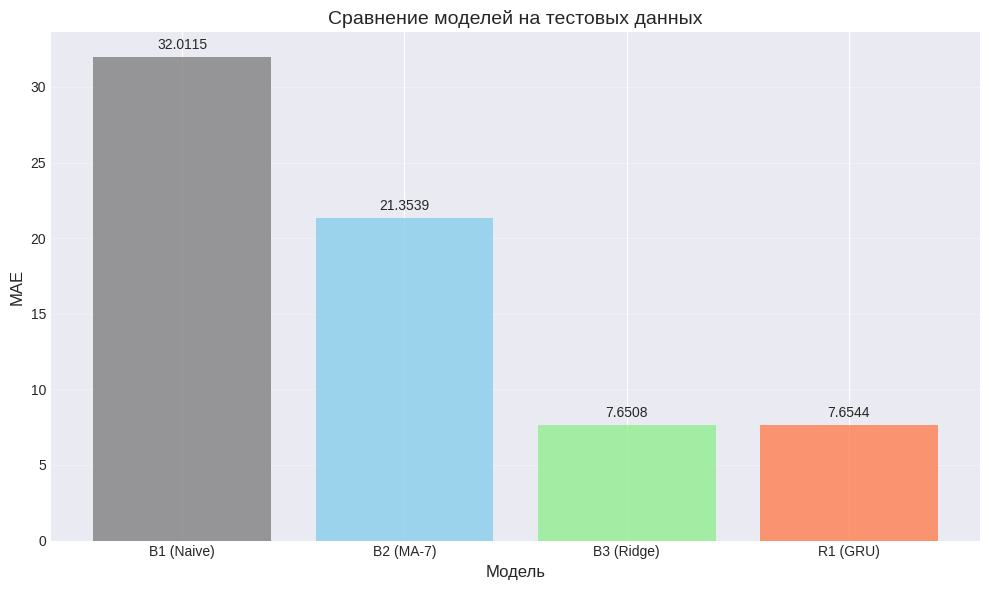

In [26]:
# Шаг 7: Оценка GRU на тесте и создание финальных артефактов

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# ============================================
# 1. Загрузка лучшей GRU модели
# ============================================
print("="*60)
print("Загрузка лучшей GRU модели")
print("="*60)

# Загружаем конфиг
config_path = os.path.join(HW12_DRIVE_PATH, 'best_gru_config.json')
with open(config_path, 'r') as f:
    best_config = json.load(f)

print(f"Конфиг загружен:")
print(f"  Window size: {best_config['window_size']}")
print(f"  Hidden size: {best_config['hidden_size']}")
print(f"  Num layers: {best_config['num_layers']}")

# Создаем модель с теми же параметрами
input_size = best_config['input_size']
model = GRUModel(input_size,
                 hidden_size=best_config['hidden_size'],
                 num_layers=best_config['num_layers'],
                 dropout=best_config['dropout']).to(device)

# Загружаем веса
model_path = os.path.join(HW12_DRIVE_PATH, 'best_gru.pt')
model.load_state_dict(torch.load(model_path, map_location=device))
print(f"Модель загружена: {model_path}")

# ============================================
# 2. Прогноз на тестовых данных
# ============================================
print("\n" + "="*60)
print("Прогноз на тестовых данных")
print("="*60)

# Создаем тестовый датасет с тем же window_size
test_dataset = TimeSeriesDataset(test_scaled_df, best_config['window_size'],
                                  'target', best_config['features'])
test_loader = DataLoader(test_dataset, batch_size=best_config['batch_size'], shuffle=False)

# Прогноз
model.eval()
test_predictions_scaled = []
test_targets_scaled = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        output = model(X)
        test_predictions_scaled.extend(output.cpu().numpy())
        test_targets_scaled.extend(y.numpy())

# Обратное масштабирование
test_predictions = scaler_gru.inverse_transform(np.array(test_predictions_scaled).reshape(-1, 1)).flatten()
test_targets = scaler_gru.inverse_transform(np.array(test_targets_scaled).reshape(-1, 1)).flatten()

# Метрики GRU на тесте
gru_test_mae, gru_test_rmse, gru_test_mape = calculate_metrics(test_targets, test_predictions)

print(f"GRU на тестовых данных:")
print(f"  MAE: {gru_test_mae:.4f}")
print(f"  RMSE: {gru_test_rmse:.4f}")
print(f"  MAPE: {gru_test_mape:.2f}%")

# ============================================
# 3. Визуализация прогноза на тесте
# ============================================
print("\n" + "="*60)
print("Визуализация прогноза")
print("="*60)

# Получаем даты для тестовых прогнозов (учитываем window_size)
test_dates = test_df['date'].iloc[best_config['window_size']:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(test_dates, test_targets, label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(test_dates, test_predictions, label='GRU Forecast', linewidth=2, color='red', alpha=0.8)

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('target', fontsize=12)
ax.set_title('GRU: Actual vs Forecast на тестовых данных', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Добавляем аннотацию с метриками
textstr = f'MAE: {gru_test_mae:.4f}\nRMSE: {gru_test_rmse:.4f}\nMAPE: {gru_test_mape:.2f}%'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
save_figure_to_drive(fig, 'best_forecast_test.png')
plt.show()

# ============================================
# 4. Анализ остатков
# ============================================
print("\n" + "="*60)
print("Анализ остатков")
print("="*60)

residuals = test_targets - test_predictions

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Остатки во времени
axes[0, 0].plot(test_dates, residuals, linewidth=1, color='purple')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[0, 0].set_title('Остатки во времени', fontsize=14)
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма остатков
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[0, 1].set_title('Распределение остатков', fontsize=14)
axes[0, 1].set_xlabel('Остатки')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot остатков', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Автокорреляция остатков
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(residuals, ax=axes[1, 1])
axes[1, 1].set_title('Автокорреляция остатков', fontsize=14)
axes[1, 1].set_xlabel('Лаг')
axes[1, 1].set_ylabel('Автокорреляция')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure_to_drive(fig, 'residuals_best.png')
plt.show()

print(f"\nСтатистика остатков:")
print(f"  Среднее: {np.mean(residuals):.6f}")
print(f"  Стандартное отклонение: {np.std(residuals):.6f}")
print(f"  Максимум: {np.max(residuals):.6f}")
print(f"  Минимум: {np.min(residuals):.6f}")

# ============================================
# 5. Создание runs.csv
# ============================================
print("\n" + "="*60)
print("Создание runs.csv")
print("="*60)

# Получаем метрики из предыдущих экспериментов
# B1, B2, B3 метрики из шага 5
# GRU метрики из шага 7

# B1
b1_val_metrics = calculate_metrics(val_df['target'], val_pred_b1)
b1_test_metrics = calculate_metrics(test_df['target'], test_pred_b1)

# B2
b2_val_metrics = calculate_metrics(val_df['target'], val_pred_b2)
b2_test_metrics = calculate_metrics(test_df['target'], test_pred_b2)

# B3
b3_val_metrics = calculate_metrics(y_val, val_pred_b3)
b3_test_metrics = calculate_metrics(y_test, test_pred_b3)

# GRU - валидационные метрики из обучения
# Используем лучшую val MAE из обучения

# Создаем список экспериментов
runs_data = []

# B1
runs_data.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': 42,
    'split_summary': f'train=60%({len(train_df)}), val=20%({len(val_df)}), test=20%({len(test_df)})',
    'window_size': 'N/A',
    'horizon': 1,
    'model_summary': 'naive_last',
    'features_summary': 'none',
    'scaler': 'none',
    'optimizer': 'N/A',
    'lr': 'N/A',
    'epochs_trained': 0,
    'best_val_mae': b1_val_metrics[0],
    'best_val_rmse': b1_val_metrics[1],
    'best_val_mape': b1_val_metrics[2],
    'test_mae': b1_test_metrics[0],
    'test_rmse': b1_test_metrics[1],
    'test_mape': b1_test_metrics[2],
    'notes': 'naive baseline: прогноз = последнее известное значение'
})

# B2
runs_data.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': 42,
    'split_summary': f'train=60%({len(train_df)}), val=20%({len(val_df)}), test=20%({len(test_df)})',
    'window_size': 7,
    'horizon': 1,
    'model_summary': 'moving_average',
    'features_summary': 'none',
    'scaler': 'none',
    'optimizer': 'N/A',
    'lr': 'N/A',
    'epochs_trained': 0,
    'best_val_mae': b2_val_metrics[0],
    'best_val_rmse': b2_val_metrics[1],
    'best_val_mape': b2_val_metrics[2],
    'test_mae': b2_test_metrics[0],
    'test_rmse': b2_test_metrics[1],
    'test_mape': b2_test_metrics[2],
    'notes': 'moving average baseline с окном 7'
})

# B3
runs_data.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': 42,
    'split_summary': f'train=60%({len(train_df)}), val=20%({len(val_df)}), test=20%({len(test_df)})',
    'window_size': 'N/A',
    'horizon': 1,
    'model_summary': f'Ridge(alpha=1.0)',
    'features_summary': ','.join(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'N/A',
    'lr': 'N/A',
    'epochs_trained': 0,
    'best_val_mae': b3_val_metrics[0],
    'best_val_rmse': b3_val_metrics[1],
    'best_val_mape': b3_val_metrics[2],
    'test_mae': b3_test_metrics[0],
    'test_rmse': b3_test_metrics[1],
    'test_mape': b3_test_metrics[2],
    'notes': 'ridge regression на лаговых и календарных признаках'
})

# R1 (GRU)
# Валидационные метрики берем из лучшей модели
best_val_mae = best_val_mae  # из обучения GRU
# Нам нужно получить val_rmse и val_mape для лучшей модели
# Для этого сделаем валидацию на лучшей модели
model.load_state_dict(torch.load(model_path, map_location=device))
val_loss, val_mae, val_rmse, val_mape = validate(model, val_loader, criterion, device)

runs_data.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': 42,
    'split_summary': f'train=60%({len(train_df)}), val=20%({len(val_df)}), test=20%({len(test_df)})',
    'window_size': best_config['window_size'],
    'horizon': 1,
    'model_summary': f'GRU(hidden={best_config["hidden_size"]}, layers={best_config["num_layers"]}, dropout={best_config["dropout"]})',
    'features_summary': 'target only',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': best_config['learning_rate'],
    'epochs_trained': best_config['best_epoch'],
    'best_val_mae': val_mae,
    'best_val_rmse': val_rmse,
    'best_val_mape': val_mape,
    'test_mae': gru_test_mae,
    'test_rmse': gru_test_rmse,
    'test_mape': gru_test_mape,
    'notes': f'GRU с window_size={best_config["window_size"]}'
})

# Сохраняем runs.csv
runs_df = pd.DataFrame(runs_data)
runs_csv_path = os.path.join(HW12_DRIVE_PATH, 'artifacts', 'runs.csv')
runs_df.to_csv(runs_csv_path, index=False)
print(f"✓ runs.csv сохранен: {runs_csv_path}")

# ============================================
# 6. Финальное сравнение всех моделей
# ============================================
print("\n" + "="*60)
print("Финальное сравнение всех моделей")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['B1 (Naive)', 'B2 (MA-7)', 'B3 (Ridge)', 'R1 (GRU)'],
    'Val MAE': [b1_val_metrics[0], b2_val_metrics[0], b3_val_metrics[0], val_mae],
    'Test MAE': [b1_test_metrics[0], b2_test_metrics[0], b3_test_metrics[0], gru_test_mae],
    'Test RMSE': [b1_test_metrics[1], b2_test_metrics[1], b3_test_metrics[1], gru_test_rmse],
    'Test MAPE (%)': [b1_test_metrics[2], b2_test_metrics[2], b3_test_metrics[2], gru_test_mape]
})

print(comparison_df.to_string(index=False))

# Визуализация финального сравнения
fig, ax = plt.subplots(figsize=(10, 6))

models = comparison_df['Model'].tolist()
test_mae = comparison_df['Test MAE'].tolist()

bars = ax.bar(models, test_mae, color=['gray', 'skyblue', 'lightgreen', 'coral'], alpha=0.8)
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Сравнение моделей на тестовых данных', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, val in zip(bars, test_mae):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(test_mae),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_figure_to_drive(fig, 'final_comparison.png')
plt.show()
